# **DecisionTree**

# **1. Decision Tree(CART : Classification and Regression Tree)**

**모델구분**  
- **`Decision Tree`** 모델은 **supervised learning**모델.  
- **prediction/classification이 모두 가능**

**모델 구조 및 특징**  
- 노드단위로 구성되어 나무가 가지를 펼쳐 나가는 듯한 직관적인 모델 구조를 갖는다.  
- 학습데이터를 100% 정확도로 예측/분류가 가능하다.  
- 위 특징으로 인해 모델 구조적으로 overfitting 문제가 있어 가지치기를 통한 해결이 필요하다.  

**학습**  
- 불순도를 기반으로 스무고개 게임을 하듯 여러 개의 hypothesis을 데이터에 반영하고 이를 바탕으로 decision boundary(결정경계)를 생성  
- 결정경계에 속한 데이터를 예측/분류 결과에 사용한다.  

**효과 및 활용**  
- ML, DL모델을 통틀어 예측/분류 결과에 따른 해석이 가장 좋다.  
- 이에 따라 **모델 해석이 필요한 문제/필드에 사용**한다. ex)신용평가, 모델분류  

## **2. 모델구조**
- root node(뿌리노드) : 최상위 노드, 모든 샘플 포함  
- leaf node(잎노드) : 최하위 노드, 여기에 속한 샘플이 모델 예측/분류 결과에 사용  
- node(노드) : 결정경계에 해당하는 모든 영역을 노드로 판단한다.    
- 가지(branch) : 노드를 나누는 기준, 가정, hypothesis  
- 깊이(depth) : 뿌리 노드와 잎 노드 까지의 노드 갯수

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/27.png">

## **3. 모델학습**
### **3.1 impurity(불순도)**
- **`DecisionTree`** 모델이 데이터를 학습하는 과정에서 사용하는 수치척도   
- 정보화 이론에서 사용하는 Gini index, 혹은 entropy를 사용한다.  
- 결정경계에 포함 된 데이터 중 다른 클래스가 포함 된 경우 불순도가 높은 상태  
- 판단기준은 불순도 값이 0.5에 가까수록 impurity가 높고 0 혹은 1에 가까울 수록 purity(순도)가 높다.  
- 즉, 한 노드의 impurity가 가능한 많이 떨어지도록(순도가 올라가도록, 값이 0으로 수렴하게) 노드를 나눈다.

$$ Gini = 1 - \sum_1^n{(p_i)^2} $$
$$ G_{split} = \sum_1^n \frac{N_i} {N} G_{i'}$$
$$ Entropy = - \sum_1^n{p_ilog(p_i)} $$



### **3.2 Gini index**
위 예시에서 뿌리 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>X < 0
>> True = class1 3개, class2 4개  
$1 - ({3 \over 3+4})^2 - ({4 \over 3+4})^2 = 0.48$  
False = class1 4개, class2 3개  
$1 - ({4 \over 4+3})^2 - ({3 \over 4+3})^2 = 0.48$  
total Gini 계수  
$({7 \over 7+7})0.48 + ({7 \over 7+7})0.48 = 0.48$


위 예시에서 잎 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>Y < 1
>> True = class1 3개, class2 0개  
$1 - ({3 \over 3})^2 - ({0 \over 3})^2 = 0$  
False = class1 0개, class2 4개  
$1 - ({0 \over 4})^2 - ({4 \over 4})^2 = 0$  
total Gini 계수  
$({3 \over 3+4})0 + ({4 \over 3+4})0 = 0$

위의 예시에서 계산한 total Gini index가 **`DecisionTree`** 모델이 학습을 하는 과정에서 불순도를 참고하는 수치가 되며  
이를 바탕으로 더 나은 선택(곧 gini index를 가장 많이 감소시키는 가정)을 하게 되는 결정경계를 생성한다.  
이를 greedy(탐욕화) 알고리즘이라 한다.

## **4. DecisionTreeClassifier 실습**

In [ ]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris # 사이킷런에서 제공하는 샘플 데이터셋 로딩

In [ ]:
# scikit-learn iris 데이터로드 / 로딩 데이터 확인
iris = load_iris(as_frame=True)
df = iris['frame']

In [ ]:
# 타겟데이터 분리
y = df['target']
X = df.drop('target', axis=1)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# 학습데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# 기본값은 0.75 : 0.25
X_train.shape, X_test.shape

((105, 4), (45, 4))

In [ ]:
# 모델 import
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# 모델 생성
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# 모델 학습
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# 모델 예측
dtc_pred = dtc.predict(X_test)

In [ ]:
# 모델 평가
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, dtc_pred))
print(classification_report(y_test, dtc_pred))

[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## **5. 분류 모델 평가방법 리뷰**

### **5.1 classification 모델평가**
> 분류모델인 **`DecisionTree`** 모델은 분류모델 평가 지표를 사용하여 모델을 평가한다.  
대표적인 모델평가 함수인 **오차행렬(confusion matrix)** 와 **분류평가표(classification report)** 를 사용한다.

### **5.2 confusion matrix(오차행렬)**  

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/21.png">

TP - True Positive(실제값 1, 예측값 1로 정분류 된 갯수)  
FN - False Negative(실제값 1, 예측값 0으로 오분류 된 갯수)  
FP - Flase Positive(실제값 0, 예측값 1로 오분류 된 갯수)  
TN - True Negative(실제값 0, 예측값 0으로 정분류 된 갯수)

### **5.3 정확도(Accuracy)** - 전체 샘플 중 모델이 바르게 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/22.png">

$${TP + TN \over TP + FN + FP + TN}$$

### **5.4 정밀도(Precision)** - 모델이 positive로 분류한 것 중 실제값이 positive이 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/23.png">

$${TP \over TP + FP}$$

### **5.5 재현율(Recall)** - 실제값이 positive인 것 중 모델이 positive라 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/24.png">

$${TP \over TP + FN}$$

### **5.6 f1-score** - precision과 recall의 조화평균
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/25.png">

$${2 * precision * recall \over precision + recall}$$  

## **6. 모델 해석을 위한 시각화 방법**
- **`DecisionTree`** 모델은 모든 Ai 모델을 통틀어 모델 전체 구조에 대한 설명이 모두 가능한 유일한 모델이다.  
- 모델의 최대 강점을 살려 전체 모델 구조에 대한 시각화를 진행한다.  
- `plot_tree()` 함수 활용

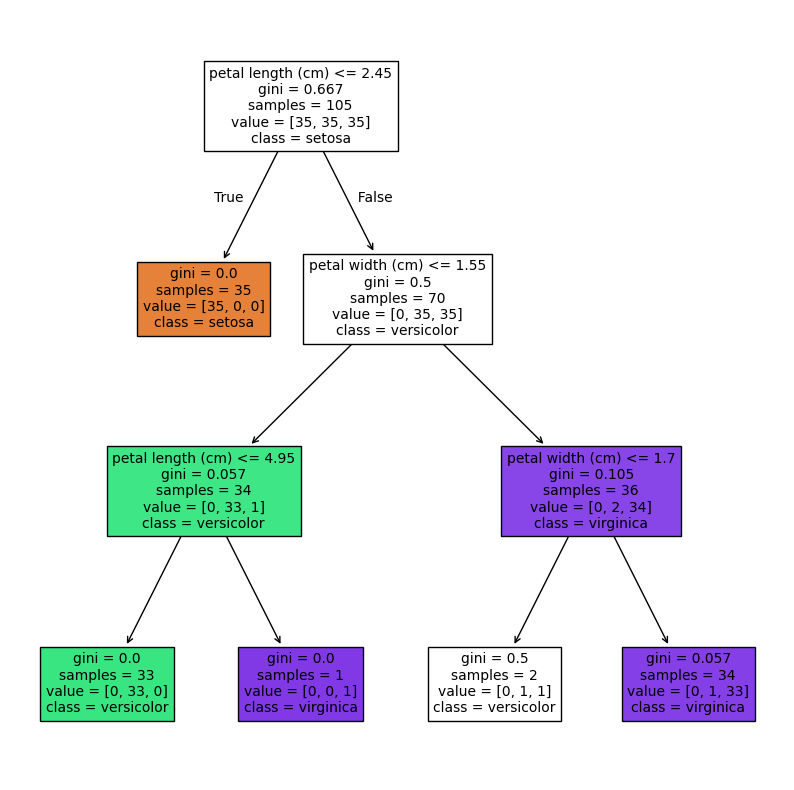

In [ ]:
# 모델 시각화
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 10))
plot_tree(dtc,
         feature_names=iris['feature_names'],
         class_names=iris['target_names'],
         filled=True);

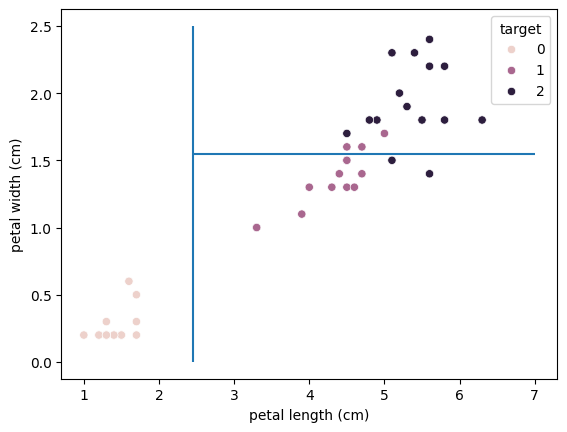

In [ ]:
# 모델 학습과정 시각화
import seaborn as sns
sns.scatterplot(data=X_test, x='petal length (cm)', y='petal width (cm)', hue=y_test) # hue 범례표시
plt.vlines(2.45, 0, 2.5)
plt.hlines(1.55, 2.45, 7)

## **7. feature importance(변수중요도)**
- 트리 기반 모델은 모델 학습 후 학습에 사용한 어떤 변수가 모델 결과값에 중요하게 사용되었는지 확인이 가능하다.  
- imformation gain값을 정규화
- feature_importances_ 속성값을 통해 트리를 분기하는 과정에서 어떤 변수가 모델의 결과값에 중요하게 사용 되었는지 확인 가능

<BarContainer object of 4 artists>

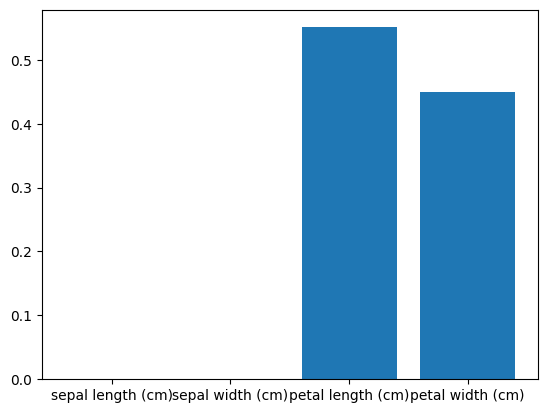

In [ ]:
# feature importance 시각화
# 변수중요도, 선형모델의 beta랑은 값의 의미가 다름
plt.bar(iris['feature_names'], dtc.feature_importances_)

# **8. 과적합(overfitting)**  
- 학습 데이터로 학습한 모델의 테스트 데이터 예측 성능이 떨어지는 경우  
- 모델이 일반화를 잘 못 시키는 상태. 실제 데이터 예측을 잘 못한다고 해석이 가능합니다.
<div align="center">
  <img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/16.png">
</div>

**overfitting**문제는 머신러닝 모델링에 있어 자주 발생하는 문제로서 모델의 복잡도를 개선하여 해결할 수 있습니다.  

### **8.1 pruning(가지치기)**
- **`Decision Tree`** 는 모든 **모든 잎 노드의 불순도가 0이 되는 순간까지 모델을 성장**시키면서 크기를 키워나간다.  
- 순수 노드로만 이루어진 트리 모델은 **training 데이터** 를 100% 정확도로 맞출 수 있고 이러한 특성 때문에 트리 모델은 **overfitting에 취약**하다.  
- 과적합 방지를 위해서는 **트리의 복잡도를 제어** 할 필요가 있다.

- 과적합 방지를 위한 모델링 파라메터  
> **`max_depth`** : 트리의 최대 깊이  
> `max_leaf_nodes` : 잎 노드의 최대개수  
> `min_sample_leaf` : 잎 노드 구성 최소 샘플 갯수  
> `min_sample_split` : 잎 노드 분지 최소 샘플 갯수

위의 모델플로팅 결과를 바탕으로 적정 복잡도를 지닌 depth를 선택 해준다면 overfitting 된 현재 모델을 개선할 수 있습니다.  
트리 모델의 경우 모델 복잡도를 제어하기 위한 하이퍼 파라메터 튜닝이 필수입니다.

# **9. Decision Tree Regressor**
- **`Decision Tree`** 모델은 분류 및 예측 모델링에 모두 사용이 가능. 하지만 모델 구분은 필요.  
- 잎 노드에 속한 학습샘플의 값의 평균을 바탕으로 예측값을 결정한다.  
- 회귀모델 평가 방법인 MSE를 사용하여 각 노드에 속한 샘플에 적용하고 오차가 가장 작아지는 가정을 반영하는 방향으로 분기를 수행한다.

$$Cost = \sum_{i \in R_1} (y_i - \hat{y}_{R_1})^2 + \sum_{i \in R_2} (y_i - \hat{y}_{R_2})^2$$

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/28.png">

## **10. Decision Tree Regressor 모델 특징**

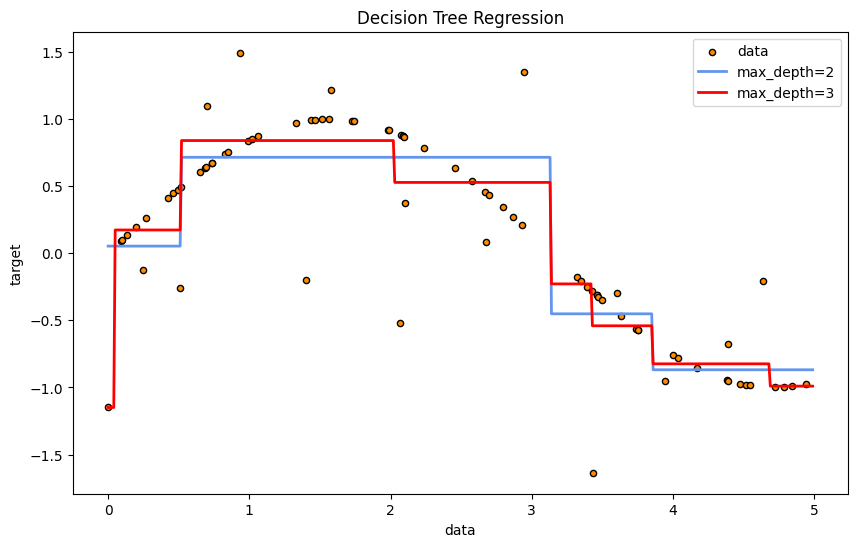

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_3 = DecisionTreeRegressor(max_depth=3)
regr_1.fit(X, y)
regr_2.fit(X, y)
regr_3.fit(X, y)
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
# plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.plot(X_test, y_3, color="red", label="max_depth=3", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## **11. Decision Tree Regressor 실습**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/refs/heads/main/data/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,y
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
y = df['y']
X = df.drop('y', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
dtr = DecisionTreeRegressor(max_depth=15, random_state=42)
dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)
print(f"R2 score : {r2_score(y_test, dtr_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test, dtr_pred)}")

R2 score : 0.8593731880046497
RMSE : 3.2370571637853427


In [ ]:
'''dtr
R2 score : 0.8444833592340152
RMSE : 3.404119021977562
'''

In [ ]:
# r2 13개의 설명변수로 모델링 한 모델이 보스턴 주택데이터 변동을 약 84.44% 설명 가능한다.
# r2 값이 크면 클수록 좋은 모델 0 < r2 < 1
# 모델의 예측값이 평균적으로 3.4(y단위에 맞춰 해석)만 달러 오차를 보인다.
# rmse 모델의 예측력, 값이 작으면 작을수록 좋은 모델

<BarContainer object of 13 artists>

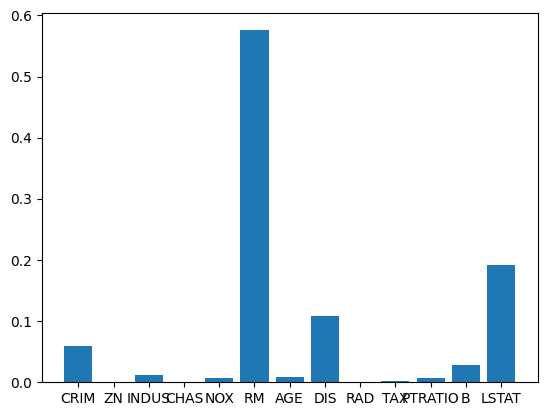

In [ ]:
# 변수 중요도
plt.bar(X_train.columns, dtr.feature_importances_)
# 모델 구조
# plot_tree(dtr)
#